In [1]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch.nn.functional as F

# --- 配置 ---
LOG_DIR = "/data/account/liuchuni/code/fsad_big_model/defect_lvlms/output/exps_KeAD_training/KolektorSDD2_vit_large_14_518_few_shot_4_vv_res_training/adjusted_text_features/"
TOTAL_EPOCHS = 100 # 你的总训练轮数

def load_all_embeddings(log_dir, total_epochs):
    """加载所有保存的嵌入向量"""
    embeddings = {
        "base_normal": [], "base_anomaly": [],
        "adj_normal": [], "adj_anomaly": [], "compensation": []
    }
    
    # 加载基准嵌入
    try:
        embeddings["base_normal"] = torch.load(os.path.join(log_dir, "base_normal_embedding.pt"))
        embeddings["base_anomaly"] = torch.load(os.path.join(log_dir, "base_anomaly_embedding.pt"))
    except FileNotFoundError:
        print("Error: Base embedding files not found. Please run the updated training script first.")
        return None

    # 加载每个epoch的嵌入
    for epoch in range(1, total_epochs + 1):
        norm_path = os.path.join(log_dir, f"adjusted_normal_epoch_{epoch:04d}.pt")
        anom_path = os.path.join(log_dir, f"adjusted_anomaly_epoch_{epoch:04d}.pt")
        comp_path = os.path.join(log_dir, f"compensation_embedding_epoch_{epoch:04d}.pt")
        
        if os.path.exists(norm_path) and os.path.exists(anom_path) and os.path.exists(comp_path):
            embeddings["adj_normal"].append(torch.load(norm_path))
            embeddings["adj_anomaly"].append(torch.load(anom_path))
            embeddings["compensation"].append(torch.load(comp_path))
        else:
            print(f"Warning: Missing embedding file for epoch {epoch}. Stopping.")
            break
            
    return embeddings

def plot_similarity_over_time(embeddings, total_epochs):
    """绘制相似度随时间变化的曲线图"""
    if not embeddings or not embeddings["adj_normal"]:
        return
        
    epochs = range(1, len(embeddings["adj_normal"]) + 1)
    
    # 1. 'adjusted_normal' vs 'adjusted_anomaly'
    sim_norm_anom = [F.cosine_similarity(n, a).item() for n, a in zip(embeddings["adj_normal"], embeddings["adj_anomaly"])]
    
    # 2. 'adjusted_normal' vs 'base_normal' (显示调整幅度)
    sim_adj_base_norm = [F.cosine_similarity(n, embeddings["base_normal"]).item() for n in embeddings["adj_normal"]]
    
    # 3. 'compensation' vs 'base_normal' (显示补偿向量学习的方向)
    # 归一化 compensation vector 以获得纯方向
    comp_normalized = [c / c.norm() for c in embeddings["compensation"]]
    sim_comp_base_norm = [F.cosine_similarity(c, embeddings["base_normal"]).item() for c in comp_normalized]

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axs = plt.subplots(3, 1, figsize=(12, 18), sharex=True)
    fig.suptitle(f'Embedding Similarity Dynamics During Training', fontsize=16)

    # 图1
    axs[0].plot(epochs, sim_norm_anom, label="sim(adj_normal, adj_anomaly)", color='r')
    axs[0].set_ylabel("Cosine Similarity")
    axs[0].set_title("Semantic Separation")
    axs[0].legend()
    axs[0].text(0.95, 0.05, 'Expected to Decrease', transform=axs[0].transAxes, ha='right', style='italic', color='gray')

    # 图2
    axs[1].plot(epochs, sim_adj_base_norm, label="sim(adj_normal, base_normal)", color='g')
    axs[1].set_ylabel("Cosine Similarity")
    axs[1].set_title("Adjustment Magnitude for 'Normal' Embedding")
    axs[1].legend()
    axs[1].text(0.95, 0.05, 'A value < 1.0 indicates adjustment', transform=axs[1].transAxes, ha='right', style='italic', color='gray')
    
    # 图3
    axs[2].plot(epochs, sim_comp_base_norm, label="sim(compensation, base_normal)", color='b')
    axs[2].set_xlabel("Epoch")
    axs[2].set_ylabel("Cosine Similarity")
    axs[2].set_title("Compensation Vector Alignment")
    axs[2].legend()
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("similarity_dynamics.png")
    print("Saved similarity dynamics plot to similarity_dynamics.png")
    plt.close()

def plot_tsne_map(embeddings, total_epochs):
    """绘制t-SNE降维分布图"""
    if not embeddings or not embeddings["adj_normal"]:
        return
        
    points_to_plot = []
    labels = []

    # 选择几个关键时间点
    epoch_indices = [0, len(embeddings["adj_normal"]) // 2, len(embeddings["adj_normal"]) - 1]

    # 添加基准点
    points_to_plot.append(embeddings["base_normal"].squeeze())
    labels.append("Base Normal")
    points_to_plot.append(embeddings["base_anomaly"].squeeze())
    labels.append("Base Anomaly")

    # 添加不同时间点的演变
    for i in epoch_indices:
        epoch_num = i + 1
        points_to_plot.append(embeddings["adj_normal"][i].squeeze())
        labels.append(f"Adj. Normal (E{epoch_num})")
        points_to_plot.append(embeddings["adj_anomaly"][i].squeeze())
        labels.append(f"Adj. Anomaly (E{epoch_num})")
        points_to_plot.append(embeddings["compensation"][i].squeeze())
        labels.append(f"Compensation (E{epoch_num})")

    # 运行 t-SNE
    all_points = torch.stack(points_to_plot).numpy()
    tsne = TSNE(n_components=2, perplexity=min(5, len(all_points)-1), random_state=42, n_iter=1000)
    points_2d = tsne.fit_transform(all_points)

    # 绘制
    plt.figure(figsize=(14, 12))
    plt.title('t-SNE Visualization of Embedding Space', fontsize=16)
    
    # 定义颜色和标记
    colors = plt.cm.get_cmap('tab20', len(labels))
    markers = {}
    for label in labels:
        if "Base" in label: markers[label] = 'X' # 大X
        elif "Normal" in label: markers[label] = 'o' # 圆
        elif "Anomaly" in label: markers[label] = 's' # 方块
        elif "Compensation" in label: markers[label] = '^' # 三角
    
    for i, (point, label) in enumerate(zip(points_2d, labels)):
        plt.scatter(point[0], point[1], marker=markers[label], s=150, color=colors(i), label=label, edgecolors='black', alpha=0.8)
        plt.annotate(label, (point[0] + 0.1, point[1] + 0.1), fontsize=9)

    # 绘制轨迹箭头
    for i in range(len(epoch_indices) - 1):
        start_idx = epoch_indices[i]
        end_idx = epoch_indices[i+1]
        
        # Normal 轨迹
        start_point_norm = points_2d[labels.index(f'Adj. Normal (E{start_idx+1})')]
        end_point_norm = points_2d[labels.index(f'Adj. Normal (E{end_idx+1})')]
        plt.arrow(start_point_norm[0], start_point_norm[1], end_point_norm[0]-start_point_norm[0], end_point_norm[1]-start_point_norm[1],
                  color='green', alpha=0.3, width=0.05, head_width=0.3)

        # Anomaly 轨迹
        start_point_anom = points_2d[labels.index(f'Adj. Anomaly (E{start_idx+1})')]
        end_point_anom = points_2d[labels.index(f'Adj. Anomaly (E{end_idx+1})')]
        plt.arrow(start_point_anom[0], start_point_anom[1], end_point_anom[0]-start_point_anom[0], end_point_anom[1]-start_point_anom[1],
                  color='red', alpha=0.3, width=0.05, head_width=0.3)

    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("tsne_map.png")
    print("Saved t-SNE map plot to tsne_map.png")
    plt.close()


if __name__ == '__main__':
    print("Loading embeddings...")
    all_embeddings = load_all_embeddings(LOG_DIR, TOTAL_EPOCHS)
    
    if all_embeddings:
        print("Generating similarity dynamics plot...")
        plot_similarity_over_time(all_embeddings, TOTAL_EPOCHS)
        
        print("\nGenerating t-SNE map...")
        plot_tsne_map(all_embeddings, TOTAL_EPOCHS)
        
        print("\nVisualization complete.")

Loading embeddings...
Generating similarity dynamics plot...


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f33ce04e0e0>
Traceback (most recent call last):
  File "/data/account/liuchuni/.conda/envs/llm2clip/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/data/account/liuchuni/.conda/envs/llm2clip/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/data/account/liuchuni/.conda/envs/llm2clip/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/data/account/liuchuni/.conda/envs/llm2clip/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Saved similarity dynamics plot to similarity_dynamics.png

Generating t-SNE map...


/tmp/ipykernel_764357/3638430527.py:128: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(labels))


Saved t-SNE map plot to tsne_map.png

Visualization complete.


In [23]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch.nn.functional as F

# --- 配置 ---
LOG_DIR = "/data/account/liuchuni/code/fsad_big_model/defect_lvlms/output/exps_KeAD_training/KolektorSDD2_vit_large_14_518_few_shot_4_vv_res_training_dual_soft/adjusted_text_features/"
TOTAL_EPOCHS = 10  # 你的总训练轮数
SAVE_INTERVAL = 1  # 每10个epoch保存一次

def load_all_embeddings(log_dir, total_epochs, save_interval):
    """加载所有保存的嵌入向量"""
    embeddings = {
        "base_normal": [], "base_anomaly": [],
        "adj_normal": [], "adj_anomaly": []
    }
    
    # 加载基准嵌入
    try:
        embeddings["base_normal"] = torch.load(os.path.join(log_dir, "base_normal_embedding.pt"))
        embeddings["base_anomaly"] = torch.load(os.path.join(log_dir, "base_anomaly_embedding.pt"))
    except FileNotFoundError:
        print("Error: Base embedding files not found. Please run the updated training script first.")
        return None
    
    # 加载每个保存间隔的嵌入
    for epoch in range(save_interval, total_epochs + 1, save_interval):
        norm_path = os.path.join(log_dir, f"adjusted_normal_epoch_{epoch:04d}.pt")
        anom_path = os.path.join(log_dir, f"adjusted_anomaly_epoch_{epoch:04d}.pt")
        
        if os.path.exists(norm_path) and os.path.exists(anom_path):
            embeddings["adj_normal"].append((epoch, torch.load(norm_path)))
            embeddings["adj_anomaly"].append((epoch, torch.load(anom_path)))
        else:
            print(f"Warning: Missing embedding file for epoch {epoch}. Stopping.")
            break
    
    # 确保按epoch顺序排列
    for key in ["adj_normal", "adj_anomaly"]:
        embeddings[key].sort(key=lambda x: x[0])
            
    return embeddings

def plot_similarity_over_time(embeddings, total_epochs, save_interval):
    """绘制相似度随时间变化的曲线图"""
    if not embeddings or not embeddings["adj_normal"]:
        return
    
    # 提取epoch编号和对应的嵌入
    epochs = [epoch for epoch, _ in embeddings["adj_normal"]]
    adj_normal_embeds = [embed for _, embed in embeddings["adj_normal"]]
    adj_anomaly_embeds = [adj_normal_embeds[0] for _, embed in embeddings["adj_anomaly"]]  # embed
    
    # 1. 'adjusted_normal' vs 'adjusted_anomaly'
    sim_norm_anom = [F.cosine_similarity(n, a).item() for n, a in zip(adj_normal_embeds, adj_anomaly_embeds)]
    
    # 2. 'adjusted_normal' vs 'base_normal' (显示调整幅度)
    sim_adj_base_norm = [F.cosine_similarity(n, embeddings["base_normal"]).item() for n in adj_normal_embeds]
    
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axs = plt.subplots(2, 1, figsize=(12, 18), sharex=True)
    fig.suptitle(f'Embedding Similarity Dynamics During Training (Every {save_interval} Epochs)', fontsize=16)
    
    # 图1
    axs[0].plot(epochs, sim_norm_anom, label="sim(adj_normal, adj_anomaly)", color='r', marker='o')
    axs[0].set_ylabel("Cosine Similarity")
    axs[0].set_title("Semantic Separation")
    axs[0].legend()
    axs[0].text(0.95, 0.05, 'Expected to Decrease', transform=axs[0].transAxes, ha='right', style='italic', color='gray')
    
    # 图2
    axs[1].plot(epochs, sim_adj_base_norm, label="sim(adj_normal, base_normal)", color='g', marker='o')
    axs[1].set_ylabel("Cosine Similarity")
    axs[1].set_title("Adjustment Magnitude for 'Normal' Embedding")
    axs[1].legend()
    axs[1].text(0.95, 0.05, 'A value < 1.0 indicates adjustment', transform=axs[1].transAxes, ha='right', style='italic', color='gray')

    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("similarity_dynamics.png")
    print("Saved similarity dynamics plot to similarity_dynamics.png")
    plt.close()

def plot_tsne_map(embeddings, total_epochs, save_interval):
    """绘制t-SNE降维分布图"""
    if not embeddings or not embeddings["adj_normal"]:
        return
        
    points_to_plot = []
    labels = []
    
    # 添加基准点
    points_to_plot.append(embeddings["base_normal"].squeeze())
    labels.append("Base Normal")
    points_to_plot.append(embeddings["base_anomaly"].squeeze())
    labels.append("Base Anomaly")
    
    # 选择几个关键时间点（开始、中间、结束）
    all_epochs = [epoch for epoch, _ in embeddings["adj_normal"]]
    selected_epochs = [all_epochs[0], all_epochs[len(all_epochs)//2], all_epochs[-1]]
    
    # 添加不同时间点的演变
    for epoch, (epoch_num, normal_embed) in enumerate(embeddings["adj_normal"]):
        if epoch_num in selected_epochs:
            normal_embed_val = normal_embed.squeeze()
            anomaly_embed_val = [anom for e, anom in embeddings["adj_anomaly"] if e == epoch_num][0].squeeze()            
            points_to_plot.append(normal_embed_val)
            labels.append(f"Adj. Normal (E{epoch_num})")
            points_to_plot.append(anomaly_embed_val)
            labels.append(f"Adj. Anomaly (E{epoch_num})")
    
    # 运行 t-SNE
    all_points = torch.stack(points_to_plot).numpy()
    tsne = TSNE(n_components=2, perplexity=min(5, len(all_points)-1), random_state=42, n_iter=1000)
    points_2d = tsne.fit_transform(all_points)
    
    # 绘制
    plt.figure(figsize=(14, 12))
    plt.title(f't-SNE Visualization of Embedding Space (Every {save_interval} Epochs)', fontsize=16)
    
    # 定义颜色和标记
    colors = plt.cm.get_cmap('tab20', len(labels))
    markers = {}
    for label in labels:
        if "Base" in label: markers[label] = 'X'  # 大X
        elif "Normal" in label: markers[label] = 'o'  # 圆
        elif "Anomaly" in label: markers[label] = 's'  # 方块
    
    for i, (point, label) in enumerate(zip(points_2d, labels)):
        plt.scatter(point[0], point[1], marker=markers[label], s=150, color=colors(i), 
                   label=label, edgecolors='black', alpha=0.8)
        plt.annotate(label, (point[0] + 0.1, point[1] + 0.1), fontsize=9)
    
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("tsne_map.png")
    print("Saved t-SNE map plot to tsne_map.png")
    plt.close()

if __name__ == '__main__':
    print("Loading embeddings...")
    all_embeddings = load_all_embeddings(LOG_DIR, TOTAL_EPOCHS, SAVE_INTERVAL)
    
    if all_embeddings:
        print("Generating similarity dynamics plot...")
        plot_similarity_over_time(all_embeddings, TOTAL_EPOCHS, SAVE_INTERVAL)
        
        print("\nGenerating t-SNE map...")
        plot_tsne_map(all_embeddings, TOTAL_EPOCHS, SAVE_INTERVAL)
        
        print("\nVisualization complete.")

Loading embeddings...
Generating similarity dynamics plot...


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f3eba7d6d40>
Traceback (most recent call last):
  File "/data/account/liuchuni/.conda/envs/llm2clip/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/data/account/liuchuni/.conda/envs/llm2clip/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/data/account/liuchuni/.conda/envs/llm2clip/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/data/account/liuchuni/.conda/envs/llm2clip/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Saved similarity dynamics plot to similarity_dynamics.png

Generating t-SNE map...


/tmp/ipykernel_3313315/1529638575.py:125: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(labels))


Saved t-SNE map plot to tsne_map.png

Visualization complete.


In [13]:
import torch
import os
import matplotlib.pyplot as plt

def plot_adjustment_dynamics(log_dir):
    """Plots the dynamics of the adjustment control variables."""
    history_path = os.path.join(log_dir, "training_history.pt")
    if not os.path.exists(history_path):
        print(f"Error: History file not found at {history_path}")
        return

    history = torch.load(history_path)
    epochs = range(1, len(history["comp_strength"]) + 1)

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axs = plt.subplots(3, 1, figsize=(12, 18), sharex=True)
    fig.suptitle('Adjustment Control Dynamics During Training', fontsize=16)

    # Plot 1: Compensation Strength
    axs[0].plot(epochs, [x.detach().cpu() for x in history["comp_strength"]], color='purple', label='comp_strength')
    axs[0].set_ylabel("Value (0 to 1)")
    axs[0].set_title("Compensation Strength (Similarity-based)")
    axs[0].legend()
    axs[0].text(0.95, 0.05, 'Reflects sim(compensation, base_normal)', transform=axs[0].transAxes, ha='right', style='italic', color='gray')

    # Plot 2: Learned Maximum Adjustment
    axs[1].plot(epochs, [x.detach().cpu() for x in history["max_t_norm"]], color='darkorange', label='max_t_norm (learned)')
    axs[1].plot(epochs, [x.detach().cpu() for x in history["max_t_anom"]], color='dodgerblue', label='max_t_anom (learned)', linestyle='--')
    axs[1].set_ylabel("Value (0 to 1)")
    axs[1].set_title("Learned Maximum Interpolation Coefficients")
    axs[1].legend()

    # Plot 3: Final Applied Adjustment
    axs[2].plot(epochs, [x.detach().cpu() for x in history["final_t_norm"]], color='darkorange', label='Final t_norm (applied)')
    axs[2].plot(epochs, [x.detach().cpu() for x in history["final_t_anom"]], color='dodgerblue', label='Final t_anom (applied)', linestyle='--')
    axs[2].set_xlabel("Epoch")
    axs[2].set_ylabel("Value (0 to 1)")
    axs[2].set_title("Final Applied Interpolation (t = max_t * comp_strength)")
    axs[2].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("adjustment_dynamics.png")
    print("Saved adjustment dynamics plot to adjustment_dynamics.png")
    plt.close()

if __name__ == '__main__':
    # ... (previous code in main)
    
    print("\nGenerating adjustment dynamics plot...")
    plot_adjustment_dynamics(LOG_DIR)
    
    print("\nVisualization complete.")


Generating adjustment dynamics plot...


/data/account/liuchuni/.conda/envs/llm2clip/lib/python3.10/site-packages/numpy/core/shape_base.py:65: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  ary = asanyarray(ary)
/data/account/liuchuni/.conda/envs/llm2clip/lib/python3.10/site-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


Saved adjustment dynamics plot to adjustment_dynamics.png

Visualization complete.


: 

Reading log file from: /data/account/liuchuni/code/fsad_big_model/defect_lvlms/output/exps_KeAD_training/KolektorSDD2_vit_large_14_518_few_shot_4_vv_res_training_dual_soft/log_train.txt
Subplots saved to loss_subplots.png


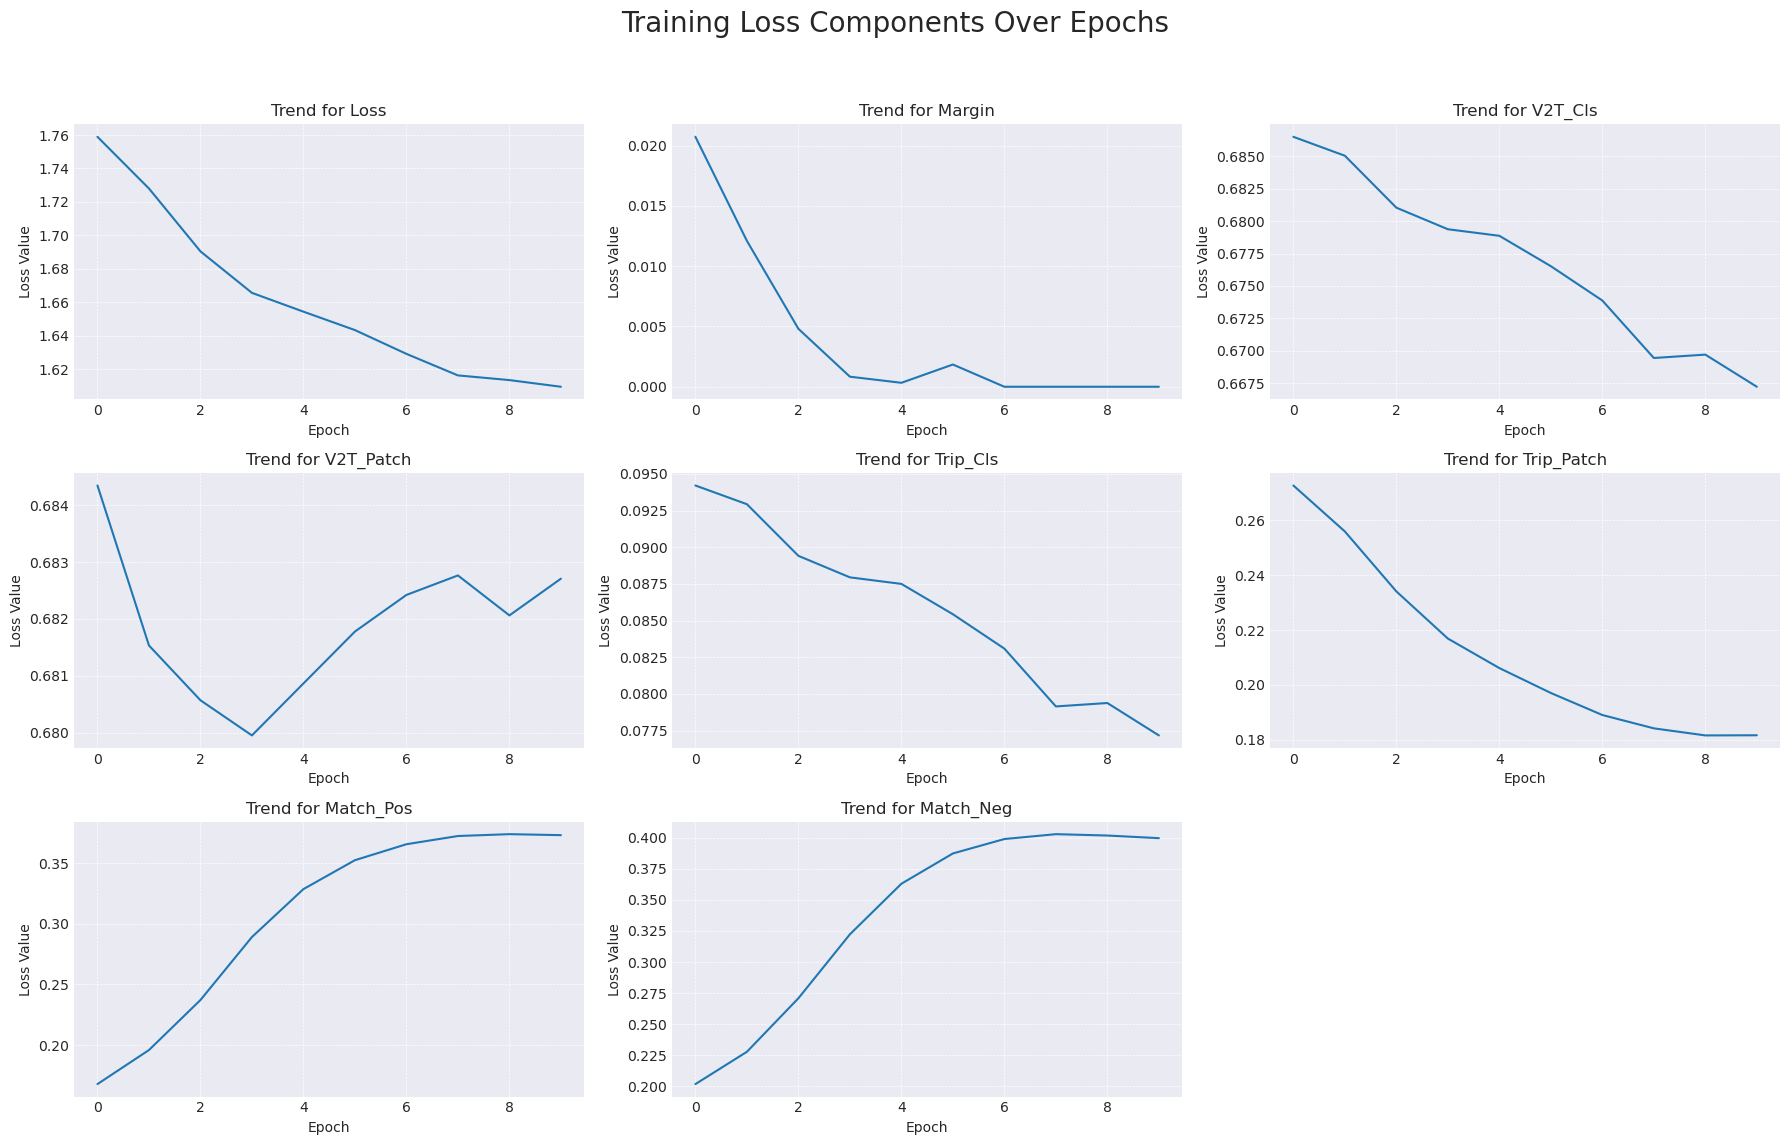

In [9]:


import re
import matplotlib.pyplot as plt
import pandas as pd
import math

def plot_loss_from_log(log_file_path):
    """
    Reads a log file, parses all loss components, and plots each 
    curve on a separate subplot.
    """
    loss_pattern = re.compile(r"([\w_]+): ([\d\.]+)")
    loss_data = {}

    print(f"Reading log file from: {log_file_path}")

    with open(log_file_path, 'r') as f:
        for line in f:
            if "Epoch [" not in line:
                continue
            matches = loss_pattern.findall(line)
            for name, value in matches:
                value = float(value)
                if name not in loss_data:
                    loss_data[name] = []
                loss_data[name].append(value)

    if not loss_data:
        print("No epoch loss data was found. Please check the log file.")
        return

    df = pd.DataFrame.from_dict(loss_data, orient='index').transpose()
    if 'Epoch' in df.columns:
        df = df.set_index('Epoch')

    # --- NEW: Subplot Plotting Logic ---
    plt.style.use('seaborn-v0_8-darkgrid')
    
    # Determine the grid size for the subplots
    num_losses = len(df.columns)
    num_cols = 3  # Let's aim for 3 columns
    num_rows = math.ceil(num_losses / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 4))
    # Flatten the axes array to make it easy to iterate over
    axes = axes.flatten()

    for i, column in enumerate(df.columns):
        ax = axes[i]
        # Plot the data for the current loss on its dedicated subplot
        ax.plot(df.index.dropna(), df[column].dropna(), label=column)
        ax.set_title(f'Trend for {column}', fontsize=12)
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel('Loss Value', fontsize=10)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
        
    fig.suptitle('Training Loss Components Over Epochs', fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
    
    plot_filename = "loss_subplots.png"
    plt.savefig(plot_filename, dpi=300)
    print(f"Subplots saved to {plot_filename}")

    plt.show()

# --- USAGE ---
# Replace this with the actual path to your log file
log_path = "/data/account/liuchuni/code/fsad_big_model/defect_lvlms/output/exps_KeAD_training/KolektorSDD2_vit_large_14_518_few_shot_4_vv_res_training_dual_soft/log_train.txt" 
plot_loss_from_log(log_path)